In [1]:
from sklearn.metrics import f1_score, precision_recall_fscore_support, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from scipy.stats import norm
import lightgbm as lgb
import xgboost as xgb
import pandas as pd
import numpy as np
from tabpfn import TabPFNClassifier

In [36]:
df = pd.read_parquet('Base_onda_Onda 1_desfecho_obito_variaveis_all.parquet')
df.head()

,idade,sexo,scv___1,scv___2,scv___3,scv___4,scv___5,scv___6,sr___1,sr___2,...,vacina,dimero_adm_final_relacao,Hometown_GDP,Hometown_DHI,Hospital_GDP,Hospital_DHI,Academic_status,Accreditation,Source_of_income,obito
index,,,,,,,,,,,,,,,,,,,,,
0,61.0,2.0,1,0,0,0,0,0,0,0,...,0.0,NaN,41476.05,0.758,38670.4,0.81,1.0,0.0,0.0,1.0
1,44.0,2.0,1,0,0,0,0,0,0,0,...,0.0,NaN,38670.40,0.810,38670.4,0.81,1.0,0.0,0.0,0.0
2,75.0,1.0,1,0,0,0,0,0,0,0,...,0.0,27.310000,38670.40,0.810,38670.4,0.81,1.0,0.0,0.0,0.0
5,60.0,1.0,1,0,0,0,0,0,0,0,...,0.0,16.981818,22999.64,0.731,38670.4,0.81,1.0,0.0,0.0,0.0
6,54.0,2.0,0,0,0,0,0,0,1,0,...,0.0,NaN,38670.40,0.810,38670.4,0.81,1.0,0.0,0.0,0.0


In [40]:
print(df[df['obito'] == 1].shape)

(1035, 62)


In [3]:
print(df.columns)

Index(['idade', 'sexo', 'scv___1', 'scv___2', 'scv___3', 'scv___4', 'scv___5',
       'scv___6', 'sr___1', 'sr___2', 'sr___3', 'dm___1', 'dm___2',
       'comorb_outras___1', 'comorb_outras___3', 'comorb_outras___4',
       'comorb_outras___5', 'comorb_outras___6', 'comorb_outras___8',
       'comorb_outras___11', 'comorb_outras_dialise', 'med_domiciliar___3',
       'med_domiciliar___6', 'med_domiciliar___7', 'med_domiciliar___13',
       'hv___1', 'hv___2', 'hv___3', 'hv___4', 'glasgow_menor15_adm_final',
       'fc_adm_final', 'fr_adm_final', 'temp_adm_final', 'sat_fio2',
       'vm_adm_final', 'hb_adm_final', 'leucocitos_adm_final',
       'neutrofilos_adm_final', 'linfocitos_adm_final', 'plaquetas_adm_final',
       'creatinina_adm_final', 'lactato_adm_final_padrao', 'pcr_adm_final',
       'sodio_adm_final', 'ast_alt', 'ureia_adm_final', 'ph_adm_final',
       'pco2_adm_final', 'bicarbonato_adm_final', 'po2_fio2_adm_final',
       'pasamina90', 'padamina60', 'vacina', 'dimero_adm

In [4]:
def IC_95(medidas):
    media = np.mean(medidas)
    erro_padrao = np.std(medidas, ddof=1) / np.sqrt(len(medidas))
    intervalo = norm.ppf(0.975) * erro_padrao  # z-score 95%
    return f"{media:.4f}({intervalo:.4f})"

def IC_95_percentage(medidas):
    media = np.mean(medidas)*100
    erro_padrao = np.std(medidas, ddof=1) / np.sqrt(len(medidas))*100
    intervalo = norm.ppf(0.975) * erro_padrao
    return f"{media:.1f}({intervalo:.1f})"

def evaluateModel(y_true_folds, y_pred_folds, classes, modelo_nome):
    macro_f1s, micro_f1s, precisao_folds, recall_folds, f1_folds = [], [], [], [], []
    
    for y_true, y_pred in zip(y_true_folds, y_pred_folds):
        macro_f1s.append(f1_score(y_true, y_pred, average="macro"))
        micro_f1s.append(f1_score(y_true, y_pred, average="micro"))
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=None, labels=classes, zero_division=0
        )
        precisao_folds.append(prec)
        recall_folds.append(rec)
        f1_folds.append(f1)

    precisao_folds = np.array(precisao_folds)
    recall_folds = np.array(recall_folds)
    f1_folds = np.array(f1_folds)

    resultados = {
        "modelo": modelo_nome,
        "macro_f1": IC_95_percentage(macro_f1s),
        "micro_f1": IC_95_percentage(micro_f1s)
    }

    for i, c in enumerate(classes):
        resultados[f"precisao_{c}"] = IC_95_percentage(precisao_folds[:, i])
        resultados[f"recall_{c}"] = IC_95_percentage(recall_folds[:, i])
        resultados[f"f1_{c}"] = IC_95_percentage(f1_folds[:, i])
    
    return resultados

def trainModels(df, target_col, classificador):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    classes = np.unique(y)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_true_folds, y_pred_folds = [], []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if classificador == "LightGBM":
            modelo = lgb.LGBMClassifier(random_state=7, verbose=-1)
        elif classificador == "XGBoost":
            modelo = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=7)
        elif classificador == "TabPFN":
            modelo = TabPFNClassifier(device='cuda', random_state=7)
        else:
            raise ValueError(f"Classificador '{classificador}' não reconhecido.")

        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        y_true_folds.append(y_test)
        y_pred_folds.append(y_pred)

    resultados = evaluateModel(y_true_folds, y_pred_folds, classes, classificador)
    return resultados



In [29]:
classificadores = ["LightGBM", "XGBoost", "TabPFN"]

resultados_gerais = []

for metodo in classificadores:
    print(f"Treinando e avaliando: {metodo}...")
    resultados = trainModels(df, target_col='obito', classificador=metodo)
    resultados_gerais.append(resultados)

df_resultados = pd.DataFrame(resultados_gerais)
df_resultados.to_csv('resultados_modelos.csv', index=False)

print("\nResultados finais:")
print(df_resultados)

Treinando e avaliando: LightGBM...
Treinando e avaliando: XGBoost...


/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:35:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:35:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:35:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:35:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain,

Treinando e avaliando: TabPFN...

Resultados finais:
     modelo   macro_f1   micro_f1 precisao_0.0 recall_0.0     f1_0.0  \
0  LightGBM  73.4(2.0)  87.1(0.9)    89.9(0.7)  95.3(0.7)  92.5(0.5)   
1   XGBoost  73.8(2.0)  87.3(0.8)    90.0(0.7)  95.4(0.4)  92.6(0.4)   
2    TabPFN  74.9(2.5)  88.2(1.0)    90.1(0.9)  96.4(0.5)  93.1(0.5)   

  precisao_1.0 recall_1.0     f1_1.0  
0    66.2(3.8)  46.1(3.7)  54.3(3.5)  
1    67.0(2.8)  46.7(4.3)  55.0(3.7)  
2    72.2(3.7)  46.7(5.1)  56.6(4.5)  


## shap geral

In [30]:
# run_tabpfn_shap_fixed.py ----------------------------------------------------
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance

from tabpfn import TabPFNClassifier
import shapiq

warnings.filterwarnings("ignore")

# -------------------------
# CONFIGURAÇÕES
# -------------------------
DF_PATH = "/home/izadoraganem/Mineracao/df_total.parquet"
SHAP_BASE_DIR = "/home/izadoraganem/Mineracao/shap"
MODELS_DIR = "/home/izadoraganem/Mineracao/models_tabpfn"
METRICS_DIR = "/home/izadoraganem/Mineracao/metrics_tabpfn"

N_SPLITS = 10
RANDOM_STATE = 42

N_EXPLAIN = 200          # <<<<<<<<<< gera summary plot
TABPFN_SAMPLE_TRAIN = 300
TABPFN_BUDGET = 64
TOP_K_FEATURES = 10
FORCE_CUDA_DEVICE = "cuda:0"
SAVE_MODELS = True

os.makedirs(SHAP_BASE_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# -------------------------
# GPU tuning
# -------------------------
device = torch.device(FORCE_CUDA_DEVICE if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# -------------------------
# Utils
# -------------------------
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

def save_fig_from_axes(outfile):
    plt.gcf().savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# FUNÇÃO PARA SUMMARY PLOT (beeswarm) IGUAL AO DA IMAGEM
# ---------------------------------------------------------
def shap_summary_plot(shap_values, X, feature_names, outfile=None):

    plt.figure(figsize=(8, 12))

    n_features = shap_values.shape[1]

    # features invertidas (igual ao SHAP original)
    for i in range(n_features):
        sv = shap_values[:, i]        # SHAP values
        fv = X[:, i]                  # feature values para cor

        # normalização para cor
        if fv.max() != fv.min():
            norm = (fv - fv.min()) / (fv.max() - fv.min())
        else:
            norm = np.zeros_like(fv)

        colors = plt.cm.coolwarm(norm)

        # jitter vertical para aparência "beeswarm"
        jitter = (np.random.rand(len(sv)) - 0.5) * 0.2

        plt.scatter(
            sv,
            np.full_like(sv, n_features - i) + jitter,
            s=12, color=colors, alpha=0.8
        )

    plt.axvline(0, color="black", linewidth=1)

    plt.yticks(range(1, n_features + 1), feature_names[::-1])
    plt.xlabel("SHAP value (impact on model output)")
    plt.title("SHAP Summary Plot (TabPFN + SHAPIQ)")
    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")
        plt.close()
    else:
        plt.show()


# -------------------------
# Função principal do fold
# -------------------------
def run_tabpfn_on_fold(X_train_np, y_train_np, X_test_np, y_test_np, feature_names, fold_idx):

    fold_dir = ensure_dir(os.path.join(SHAP_BASE_DIR, f"fold_{fold_idx}", "TabPFN"))
    model_path = os.path.join(MODELS_DIR, f"tabpfn_fold_{fold_idx}.joblib")
    metrics_path = os.path.join(METRICS_DIR, f"metrics_fold_{fold_idx}.csv")

    cache_path_template = os.path.join(
        fold_dir,
        "tabpfn_values_explainer_fold{fold}_k{K}.npz"
    )

    print(f"\n=== Fold {fold_idx} — treinamento TabPFN ===")

    # modelo principal
    model_main = TabPFNClassifier(device=device, random_state=RANDOM_STATE)
    model_main.fit(X_train_np, y_train_np)

    # métricas
    y_pred = model_main.predict(X_test_np)

    from sklearn.metrics import precision_recall_fscore_support, f1_score
    prec, rec, f1_vals, _ = precision_recall_fscore_support(
        y_test_np, y_pred, average=None, zero_division=0
    )

    macro = f1_score(y_test_np, y_pred, average="macro")
    micro = f1_score(y_test_np, y_pred, average="micro")

    metrics = {"fold": fold_idx, "macro_f1": macro, "micro_f1": micro}

    uniques = np.unique(np.concatenate([y_train_np, y_test_np]))
    for i, cls in enumerate(uniques):
        metrics[f"precisao_{cls}"] = float(prec[i])
        metrics[f"recall_{cls}"] = float(rec[i])
        metrics[f"f1_{cls}"] = float(f1_vals[i])

    pd.DataFrame([metrics]).to_csv(metrics_path, index=False)
    print("Métricas salvas em:", metrics_path)

    if SAVE_MODELS:
        joblib.dump(model_main, model_path)
        print("Modelo salvo em:", model_path)

    # -------------------------
    # Seleção das top features
    # -------------------------
    n_train_sample = min(TABPFN_SAMPLE_TRAIN, X_train_np.shape[0])
    rng = np.random.RandomState(RANDOM_STATE + fold_idx)
    sample_idx = rng.choice(X_train_np.shape[0], size=n_train_sample, replace=False)

    x_small = X_train_np[sample_idx]
    y_small = y_train_np[sample_idx]

    try:
        pi = permutation_importance(
            model_main, X_test_np, y_test_np,
            n_repeats=3, random_state=RANDOM_STATE, n_jobs=1
        )
        important_idx = np.argsort(pi.importances_mean)[::-1][:TOP_K_FEATURES]
    except Exception:
        important_idx = np.argsort(np.var(x_small, axis=0))[::-1][:TOP_K_FEATURES]

    # reduz dimensões
    x_small_sel = x_small[:, important_idx]
    X_test_sel = X_test_np[:, important_idx]
    feature_names_sel = [feature_names[i] for i in important_idx]

    # -------------------------
    # Treina modelo pequeno (apenas top features)
    # -------------------------
    model_small = TabPFNClassifier(device=device, random_state=RANDOM_STATE)
    model_small.fit(x_small_sel, y_small)

    try:
        avg_pred = float(model_small.predict(x_small_sel).mean())
    except:
        avg_pred = 0.5

    # -------------------------
    # SHAPIQ
    # -------------------------
    cache_path = cache_path_template.format(fold=fold_idx, K=len(important_idx))

    explainer = shapiq.Explainer(
        model=model_small,
        data=x_small_sel,
        labels=y_small,
        index="SV",
        max_order=1,
        empty_prediction=avg_pred,
    )

    if not Path(cache_path).exists():
        print("Criando cache SHAPIQ...")
        explainer.imputer.fit(X_test_sel[0].reshape(1, -1))
        explainer.imputer.precompute()
        explainer.imputer.save_values(cache_path)
        print("Cache salvo em:", cache_path)
    else:
        explainer.imputer.load_values(cache_path)
        print("Cache carregado:", cache_path)

    # -------------------------
    # Explicar vários exemplos (para summary plot)
    # -------------------------
    n_explain = min(N_EXPLAIN, X_test_sel.shape[0])
    all_shap_values = []

    for i in range(n_explain):
        x_explain = X_test_sel[i].reshape(1, -1)
        shapley_values = explainer.explain(x_explain, budget=TABPFN_BUDGET)

        vals = shapley_values.values
        # normaliza para 2D
        if vals.ndim == 1:
            vals = vals.reshape(1, -1)

        # caso comum: shapiq retornou K+1 (valor base incluso) -> remover a coluna extra
        if vals.shape[1] == X_test_sel.shape[1] + 1:
            # assumimos que a coluna extra é o último elemento; removemos
            vals = vals[:, :X_test_sel.shape[1]]
        elif vals.shape[1] != X_test_sel.shape[1]:
            # aviso informativo e tentativa de ajuste defensivo
            print(f"AVISO: dimensão SHAPIQ inesperada em fold {fold_idx}, exemplo {i}:",
                  f"vals.shape={vals.shape}, X_test_sel.shape[1]={X_test_sel.shape[1]}")
            # se maior, truncar; se menor, preencher com zeros (defensivo)
            if vals.shape[1] > X_test_sel.shape[1]:
                vals = vals[:, :X_test_sel.shape[1]]
            else:
                pad = np.zeros((vals.shape[0], X_test_sel.shape[1] - vals.shape[1]))
                vals = np.concatenate([vals, pad], axis=1)

        all_shap_values.append(vals.flatten())

    all_shap_values = np.array(all_shap_values)
    np.save(os.path.join(fold_dir, "all_shap_values.npy"), all_shap_values)

    # -------------------------
    # SUMMARY PLOT
    # -------------------------
    summary_outfile = os.path.join(fold_dir, "summary_plot.png")
    shap_summary_plot(
        shap_values=all_shap_values,
        X=X_test_sel[:len(all_shap_values)],
        feature_names=feature_names_sel,
        outfile=summary_outfile,
    )
    print("Summary plot salvo em:", summary_outfile)

    return metrics


# -------------------------
# Loop principal
# -------------------------
def main():

    print("Carregando:", DF_PATH)
    df = pd.read_parquet(DF_PATH)
    print("Shape DF:", df.shape)

    feature_cols = [c for c in df.columns if c != "obito"]
    X = df[feature_cols].values
    y = df["obito"].values

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    all_metrics = []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print("\n--- Fold", fold_idx, "---")
        try:
            metrics = run_tabpfn_on_fold(
                X[train_idx], y[train_idx],
                X[test_idx], y[test_idx],
                feature_cols, fold_idx
            )
            all_metrics.append(metrics)
        except Exception as e:
            print("Erro SHAPIQ TabPFN fold", fold_idx, ":", e)
            all_metrics.append({"fold": fold_idx, "error": str(e)})

    df_metrics = pd.DataFrame(all_metrics)
    out_path = os.path.join(METRICS_DIR, "tabpfn_metrics_all_folds.csv")
    df_metrics.to_csv(out_path, index=False)

    print("Métricas finais salvas em:", out_path)
    print(df_metrics)


if __name__ == "__main__":
    main()


Usando device: cuda:0
Carregando: /home/izadoraganem/Mineracao/df_total.parquet
Shape DF: (6237, 62)

--- Fold 0 ---

=== Fold 0 — treinamento TabPFN ===
Métricas salvas em: /home/izadoraganem/Mineracao/metrics_tabpfn/metrics_fold_0.csv
Modelo salvo em: /home/izadoraganem/Mineracao/models_tabpfn/tabpfn_fold_0.joblib


KeyboardInterrupt: 

In [7]:
FEATURE_NAME_MAP = {
    # Demographics
    "idade": "age",
    "sexo": "sex",

    # Cardiovascular system (SCV)
    "scv___1": "cardiovascular_disease_1",
    "scv___2": "cardiovascular_disease_2",
    "scv___3": "cardiovascular_disease_3",
    "scv___4": "cardiovascular_disease_4",
    "scv___5": "cardiovascular_disease_5",
    "scv___6": "cardiovascular_disease_6",

    # Systemic response
    "sr___1": "systemic_response_1",
    "sr___2": "systemic_response_2",
    "sr___3": "systemic_response_3",

    # Diabetes mellitus
    "dm___1": "diabetes_mellitus_1",
    "dm___2": "diabetes_mellitus_2",

    # Other comorbidities
    "comorb_outras___1": "other_comorbidities_1",
    "comorb_outras___3": "other_comorbidities_3",
    "comorb_outras___4": "other_comorbidities_4",
    "comorb_outras___5": "other_comorbidities_5",
    "comorb_outras___6": "other_comorbidities_6",
    "comorb_outras___8": "other_comorbidities_8",
    "comorb_outras___11": "other_comorbidities_11",
    "comorb_outras_dialise": "dialysis_dependent_comorbidity",

    # Home medication
    "med_domiciliar___3": "home_medication_3",
    "med_domiciliar___6": "home_medication_6",
    "med_domiciliar___7": "home_medication_7",
    "med_domiciliar___13": "home_medication_13",

    # Clinical history / habits (HV)
    "hv___1": "clinical_history_1",
    "hv___2": "clinical_history_2",
    "hv___3": "clinical_history_3",
    "hv___4": "clinical_history_4",

    # Neurological status
    "glasgow_menor15_adm_final": "glasgow_coma_scale_less_than_15",

    # Vital signs at admission
    "fc_adm_final": "heart_rate",
    "fr_adm_final": "respiratory_rate",
    "temp_adm_final": "body_temperature",
    "sat_fio2": "oxygen_saturation_fio2_ratio",
    "vm_adm_final": "mechanical_ventilation",

    # Laboratory values at admission
    "hb_adm_final": "hemoglobin",
    "leucocitos_adm_final": "leukocytes",
    "neutrofilos_adm_final": "neutrophils",
    "linfocitos_adm_final": "lymphocytes",
    "plaquetas_adm_final": "platelets",
    "creatinina_adm_final": "creatinine",
    "lactato_adm_final_padrao": "lactate",
    "pcr_adm_final": "c_reactive_protein",
    "sodio_adm_final": "sodium",
    "ast_alt": "ast_alt_ratio",
    "ureia_adm_final": "urea",
    "ph_adm_final": "blood_ph",
    "pco2_adm_final": "pco2",
    "bicarbonato_adm_final": "bicarbonate",
    "po2_fio2_adm_final": "pao2_fio2_ratio",
    "dimero_adm_final_relacao": "d_dimer_ratio",

    # Hemodynamics
    "pasamina90": "systolic_bp_below_90",
    "padamina60": "diastolic_bp_below_60",

    # Vaccination
    "vacina": "vaccination_status",

    # Socioeconomic indicators
    "Hometown_GDP": "hometown_gdp",
    "Hometown_DHI": "hometown_human_development_index",
    "Hospital_GDP": "hospital_region_gdp",
    "Hospital_DHI": "hospital_region_human_development_index",
    "Academic_status": "hospital_academic_status",
    "Accreditation": "hospital_accreditation",
    "Source_of_income": "source_of_income",

    # Outcome
    "obito": "mortality"
}


Iniciando busca por divergências (TabPFN Correto vs XGBoost Errado)...
Total de casos encontrados onde TabPFN acertou e XGBoost errou: 154

--- Analisando Caso Clínico (Index: 1346) ---
Real: 1.0 | TabPFN: 1.0 (Correto) | XGBoost: 0 (Errado)
Gerando explicação para a classe: 1


<Figure size 2800x700 with 0 Axes>

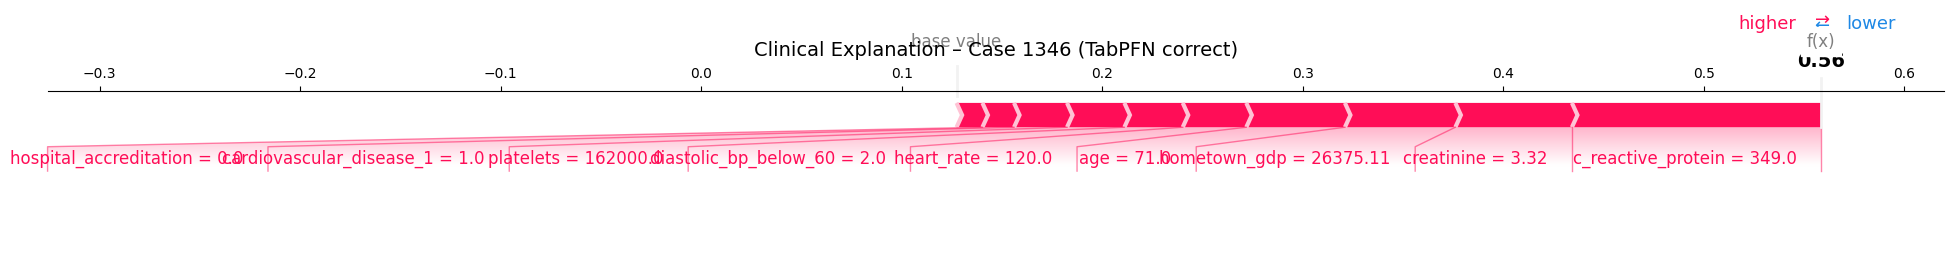

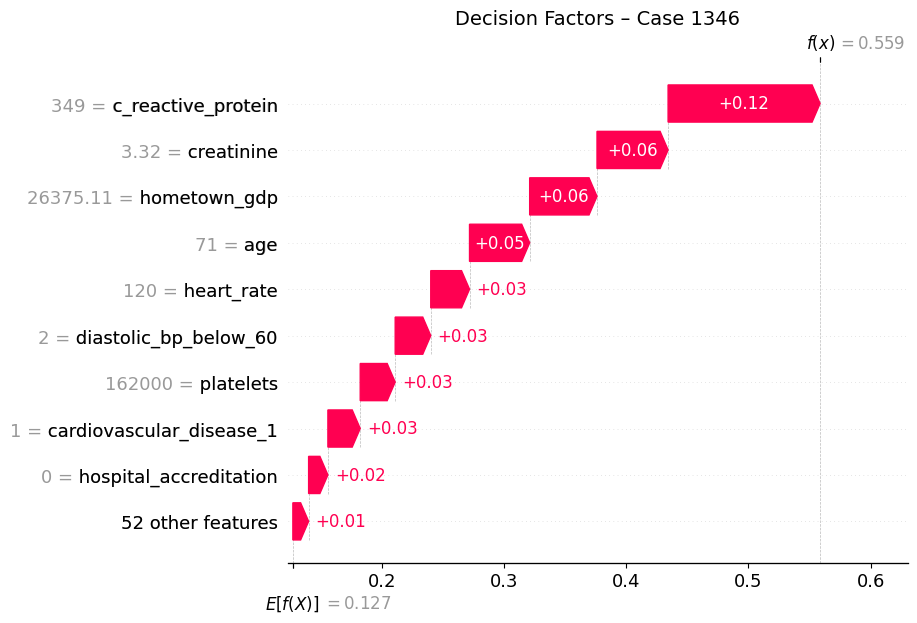

In [31]:
import shap
import pandas as pd
import numpy as np
import xgboost as xgb
from tabpfn import TabPFNClassifier
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# ==============================
# Feature name translation map
# ==============================
FEATURE_NAME_MAP = {
    "idade": "age",
    "sexo": "sex",

    "scv___1": "cardiovascular_disease_1",
    "scv___2": "cardiovascular_disease_2",
    "scv___3": "cardiovascular_disease_3",
    "scv___4": "cardiovascular_disease_4",
    "scv___5": "cardiovascular_disease_5",
    "scv___6": "cardiovascular_disease_6",

    "sr___1": "systemic_response_1",
    "sr___2": "systemic_response_2",
    "sr___3": "systemic_response_3",

    "dm___1": "diabetes_mellitus_1",
    "dm___2": "diabetes_mellitus_2",

    "comorb_outras___1": "other_comorbidities_1",
    "comorb_outras___3": "other_comorbidities_3",
    "comorb_outras___4": "other_comorbidities_4",
    "comorb_outras___5": "other_comorbidities_5",
    "comorb_outras___6": "other_comorbidities_6",
    "comorb_outras___8": "other_comorbidities_8",
    "comorb_outras___11": "other_comorbidities_11",
    "comorb_outras_dialise": "dialysis_dependent_comorbidity",

    "med_domiciliar___3": "home_medication_3",
    "med_domiciliar___6": "home_medication_6",
    "med_domiciliar___7": "home_medication_7",
    "med_domiciliar___13": "home_medication_13",

    "hv___1": "clinical_history_1",
    "hv___2": "clinical_history_2",
    "hv___3": "clinical_history_3",
    "hv___4": "clinical_history_4",

    "glasgow_menor15_adm_final": "glasgow_coma_scale_less_than_15",

    "fc_adm_final": "heart_rate",
    "fr_adm_final": "respiratory_rate",
    "temp_adm_final": "body_temperature",
    "sat_fio2": "oxygen_saturation_fio2_ratio",
    "vm_adm_final": "mechanical_ventilation",

    "hb_adm_final": "hemoglobin",
    "leucocitos_adm_final": "leukocytes",
    "neutrofilos_adm_final": "neutrophils",
    "linfocitos_adm_final": "lymphocytes",
    "plaquetas_adm_final": "platelets",
    "creatinina_adm_final": "creatinine",
    "lactato_adm_final_padrao": "lactate",
    "pcr_adm_final": "c_reactive_protein",
    "sodio_adm_final": "sodium",
    "ast_alt": "ast_alt_ratio",
    "ureia_adm_final": "urea",
    "ph_adm_final": "blood_ph",
    "pco2_adm_final": "pco2",
    "bicarbonato_adm_final": "bicarbonate",
    "po2_fio2_adm_final": "pao2_fio2_ratio",
    "dimero_adm_final_relacao": "d_dimer_ratio",

    "pasamina90": "systolic_bp_below_90",
    "padamina60": "diastolic_bp_below_60",

    "vacina": "vaccination_status",

    "Hometown_GDP": "hometown_gdp",
    "Hometown_DHI": "hometown_human_development_index",
    "Hospital_GDP": "hospital_region_gdp",
    "Hospital_DHI": "hospital_region_human_development_index",
    "Academic_status": "hospital_academic_status",
    "Accreditation": "hospital_accreditation",
    "Source_of_income": "source_of_income",

    "obito": "mortality",
}

# ==============================
# Divergence analysis
# ==============================
def analisar_divergencias_shap(df, target_col):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    casos_divergentes = []

    print("Iniciando busca por divergências (TabPFN Correto vs XGBoost Errado)...")

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model_xgb = xgb.XGBClassifier(
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=7
        )
        model_xgb.fit(X_train, y_train)
        pred_xgb = model_xgb.predict(X_test)

        model_tab = TabPFNClassifier(
            device="cuda",
            ignore_pretraining_limits=True,
            random_state=7
        )
        model_tab.fit(X_train, y_train)
        pred_tab = model_tab.predict(X_test)

        mask_divergencia = (pred_tab == y_test) & (pred_xgb != y_test)

        if np.sum(mask_divergencia) > 0:
            indices_divergentes = X_test.index[mask_divergencia].tolist()

            for idx in indices_divergentes:
                casos_divergentes.append({
                    "fold": fold_i,
                    "original_index": idx,
                    "true_label": y_test.loc[idx],
                    "xgb_pred": pred_xgb[np.where(X_test.index == idx)[0][0]],
                    "tab_pred": pred_tab[np.where(X_test.index == idx)[0][0]],
                    "row_data": X_test.loc[[idx]],
                    "model_tab_instance": model_tab,
                    "background_data": X_train.sample(50, random_state=42),
                })

    print(f"Total de casos encontrados onde TabPFN acertou e XGBoost errou: {len(casos_divergentes)}")
    return casos_divergentes

# ==============================
# SHAP clinical explanation
# ==============================
def plotar_explicacao_clinica(caso, feature_names):
    print(f"\n--- Analisando Caso Clínico (Index: {caso['original_index']}) ---")
    print(
        f"Real: {caso['true_label']} | "
        f"TabPFN: {caso['tab_pred']} (Correto) | "
        f"XGBoost: {caso['xgb_pred']} (Errado)"
    )

    model = caso["model_tab_instance"]
    row = caso["row_data"]
    background = caso["background_data"]
    classe_interesse = int(caso["true_label"])

    print(f"Gerando explicação para a classe: {classe_interesse}")

    def predict_proba_classe_interesse(X):
        return model.predict_proba(X)[:, classe_interesse]

    explainer = shap.KernelExplainer(
        predict_proba_classe_interesse,
        background
    )

    with np.errstate(all="ignore"):
        shap_values_2d = explainer.shap_values(
            row,
            nsamples=100,
            silent=True
        )

    base_value = float(explainer.expected_value)

    if isinstance(shap_values_2d, list):
        shap_values_2d = np.array(shap_values_2d)

    shap_values = shap_values_2d[0] if shap_values_2d.ndim == 2 else shap_values_2d

    row_data_np = row.values[0].astype(float)

    # 🔹 APPLY FEATURE NAME TRANSLATION HERE
    feature_names_list = [
        FEATURE_NAME_MAP.get(f, f)
        for f in feature_names.astype(str).tolist()
    ]

    assert len(feature_names_list) == len(row_data_np)

    plt.figure(figsize=(28, 7))
    plt.rcParams["font.size"] = 10
    plt.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.12)

    shap.force_plot(
        base_value,
        shap_values,
        row_data_np,
        feature_names=feature_names_list,
        matplotlib=True,
        show=False
    )

    plt.title(
        f"Clinical Explanation – Case {caso['original_index']} (TabPFN correct)",
        pad=25,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

    sv = shap.Explanation(
        values=shap_values,
        base_values=base_value,
        data=row_data_np,
        feature_names=feature_names_list
    )

    plt.figure()
    shap.plots.waterfall(sv, show=False)
    plt.title(
        f"Decision Factors – Case {caso['original_index']}",
        fontsize=14
    )
    plt.show()

# ==============================
# Run analysis
# ==============================
casos = analisar_divergencias_shap(df, target_col="obito")

if len(casos) > 0:
    caso_para_estudo = casos[0]
    plotar_explicacao_clinica(
        caso_para_estudo,
        feature_names=df.drop(columns=["obito"]).columns
    )
else:
    print("Nenhuma divergência onde TabPFN > XGBoost foi encontrada nos folds.")


In [32]:
def analisar_divergencias_shap(df, target_col):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    casos_divergentes = []

    # 🔹 GLOBAL COUNTERS
    total_samples = 0
    total_disagreements = 0
    tab_correct_in_disagreement = 0
    xgb_correct_in_disagreement = 0

    print("Iniciando análise completa de divergências...")

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        total_samples += len(X_test)

        # =====================
        # Train models
        # =====================
        model_xgb = xgb.XGBClassifier(
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=7
        )
        model_xgb.fit(X_train, y_train)
        pred_xgb = model_xgb.predict(X_test)

        model_tab = TabPFNClassifier(
            device="cuda",
            ignore_pretraining_limits=True,
            random_state=7
        )
        model_tab.fit(X_train, y_train)
        pred_tab = model_tab.predict(X_test)

        # =====================
        # Disagreement mask
        # =====================
        disagreement_mask = pred_tab != pred_xgb

        total_disagreements += np.sum(disagreement_mask)

        # =====================
        # Who is correct?
        # =====================
        tab_correct_mask = (pred_tab == y_test)
        xgb_correct_mask = (pred_xgb == y_test)

        tab_correct_in_disagreement += np.sum(disagreement_mask & tab_correct_mask)
        xgb_correct_in_disagreement += np.sum(disagreement_mask & xgb_correct_mask)

        # =====================
        # Store cases (same as before)
        # =====================
        indices_divergentes = X_test.index[disagreement_mask].tolist()

        for idx in indices_divergentes:
            casos_divergentes.append({
                "fold": fold_i,
                "original_index": idx,
                "true_label": y_test.loc[idx],
                "xgb_pred": pred_xgb[np.where(X_test.index == idx)[0][0]],
                "tab_pred": pred_tab[np.where(X_test.index == idx)[0][0]],
                "row_data": X_test.loc[[idx]],
                "model_tab_instance": model_tab,
                "background_data": X_train.sample(50, random_state=42),
            })

    # =====================
    # Final metrics
    # =====================
    if total_disagreements > 0:
        disagreement_rate = total_disagreements / total_samples
        tab_accuracy_disagreement = tab_correct_in_disagreement / total_disagreements
        xgb_accuracy_disagreement = xgb_correct_in_disagreement / total_disagreements
    else:
        disagreement_rate = 0
        tab_accuracy_disagreement = 0
        xgb_accuracy_disagreement = 0

    print("\n===== RESULTADOS GLOBAIS =====")
    print(f"Total de amostras: {total_samples}")
    print(f"Total de divergências: {total_disagreements}")
    print(f"TabPFN correto nas divergências: {tab_correct_in_disagreement}")
    print(f"XGBoost correto nas divergências: {xgb_correct_in_disagreement}")

    print("\n----- Percentuais -----")
    print(f"Disagreement rate (x%): {disagreement_rate*100:.2f}%")
    print(f"TabPFN accuracy em divergências (y%): {tab_accuracy_disagreement*100:.2f}%")
    print(f"XGBoost accuracy em divergências (z%): {xgb_accuracy_disagreement*100:.2f}%")

    return {
        "casos_divergentes": casos_divergentes,
        "metrics": {
            "total_samples": total_samples,
            "total_disagreements": total_disagreements,
            "tab_correct_in_disagreement": tab_correct_in_disagreement,
            "xgb_correct_in_disagreement": xgb_correct_in_disagreement,
            "disagreement_rate": disagreement_rate,
            "tab_accuracy_disagreement": tab_accuracy_disagreement,
            "xgb_accuracy_disagreement": xgb_accuracy_disagreement,
        }
    }

In [35]:
df = df['obito']
df.shape

KeyError: 'obito'

In [33]:
resultado = analisar_divergencias_shap(df, target_col="obito")

casos = resultado["casos_divergentes"]
metricas = resultado["metrics"]

print(metricas)

Iniciando análise completa de divergências...

===== RESULTADOS GLOBAIS =====
Total de amostras: 6237
Total de divergências: 257
TabPFN correto nas divergências: 154
XGBoost correto nas divergências: 103

----- Percentuais -----
Disagreement rate (x%): 4.12%
TabPFN accuracy em divergências (y%): 59.92%
XGBoost accuracy em divergências (z%): 40.08%
{'total_samples': 6237, 'total_disagreements': np.int64(257), 'tab_correct_in_disagreement': np.int64(154), 'xgb_correct_in_disagreement': np.int64(103), 'disagreement_rate': np.float64(0.04120570787237454), 'tab_accuracy_disagreement': np.float64(0.5992217898832685), 'xgb_accuracy_disagreement': np.float64(0.40077821011673154)}


In [41]:
casos = pd.DataFrame(casos)
casos2 = casos[casos['true_label'] == 1.0]
print(casos[casos['true_label'] == 1.0].shape)
print(casos2[casos2['tab_pred'] == 1.0].shape)
print(casos2[casos2['xgb_pred'] == 1.0].shape)
print
print(casos)

(130, 8)
(65, 8)
(65, 8)
     fold  original_index  true_label  xgb_pred  tab_pred  \
0       0            1346         1.0         0       1.0   
1       0            1381         0.0         1       0.0   
2       0            1431         1.0         1       0.0   
3       0            1559         0.0         1       0.0   
4       0            1795         1.0         1       0.0   
..    ...             ...         ...       ...       ...   
252     4            6974         1.0         0       1.0   
253     4            7127         0.0         1       0.0   
254     4            7188         1.0         1       0.0   
255     4            7649         1.0         0       1.0   
256     4           20869         1.0         1       0.0   

                                              row_data  \
0           idade  sexo  scv___1  scv___2  scv___3 ...   
1           idade  sexo  scv___1  scv___2  scv___3 ...   
2           idade  sexo  scv___1  scv___2  scv___3 ...   
3         

In [12]:
def analisar_divergencias_obito_v2(df, target_col):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    casos_divergentes_classe_1 = []

    # 1. INICIALIZAÇÃO (FORA DO LOOP)
    total_obitos_reais = 0
    tab_total_acertos_classe1 = 0
    xgb_total_acertos_classe1 = 0
    divergencias_no_obito = 0
    tab_acertou_obito_divergente = 0
    xgb_acertou_obito_divergente = 0

    print("Iniciando análise...")

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Treino
        model_xgb = xgb.XGBClassifier(eval_metric="logloss", random_state=7).fit(X_train, y_train)
        model_tab = TabPFNClassifier(device="cuda", ignore_pretraining_limits=True, random_state=7).fit(X_train, y_train)
        
        pred_xgb = model_xgb.predict(X_test)
        pred_tab = model_tab.predict(X_test)

        # 2. ACUMULADORES (DENTRO DO LOOP)
        total_obitos_reais += np.sum(y_test == 1)
        
        # Acertos totais na classe 1 (para o Recall)
        tab_total_acertos_classe1 += np.sum((pred_tab == 1) & (y_test == 1))
        xgb_total_acertos_classe1 += np.sum((pred_xgb == 1) & (y_test == 1))

        # Lógica de Divergência
        mask_obito_real = (y_test == 1)
        mask_divergencia = (pred_tab != pred_xgb)
        mask_final = mask_divergencia & mask_obito_real

        divergencias_no_obito += np.sum(mask_final)
        tab_acertou_obito_divergente += np.sum(mask_final & (pred_tab == 1))
        xgb_acertou_obito_divergente += np.sum(mask_final & (pred_xgb == 1))

        # Coleta de casos para SHAP
        indices_alvo = X_test.index[mask_final].tolist()
        for idx in indices_alvo:
            casos_divergentes_classe_1.append({
                "fold": fold_i,
                "original_index": idx,
                "xgb_pred": pred_xgb[np.where(X_test.index == idx)[0][0]],
                "tab_pred": pred_tab[np.where(X_test.index == idx)[0][0]],
                "row_data": X_test.loc[[idx]],
                "model_tab_instance": model_tab,
                "background_data": X_train.sample(50, random_state=42),
            })

    # 3. CÁLCULO FINAL (FORA DO LOOP)
    recall_tab = tab_total_acertos_classe1 / total_obitos_reais
    recall_xgb = xgb_total_acertos_classe1 / total_obitos_reais

    print("\n===== RESULTADOS FOCADOS EM ÓBITO (CLASSE 1) =====")
    print(f"Total de óbitos reais no dataset: {total_obitos_reais}")
    print(f"Recall Global TabPFN: {recall_tab*100:.2f}% (Acertou {tab_total_acertos_classe1})")
    print(f"Recall Global XGBoost: {recall_xgb*100:.2f}% (Acertou {xgb_total_acertos_classe1})")
    
    print("\n--- Confronto nas Divergências ---")
    print(f"Casos onde divergiram e era óbito: {divergencias_no_obito}")
    print(f"TabPFN acertou sozinho: {tab_acertou_obito_divergente}")
    print(f"XGBoost acertou sozinho: {xgb_acertou_obito_divergente}")

    return {"casos": casos_divergentes_classe_1, "total_obitos": total_obitos_reais}

# Chamar a função
resultado = analisar_divergencias_obito_v2(df, target_col="obito")

Iniciando análise...


analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full



===== RESULTADOS FOCADOS EM ÓBITO (CLASSE 1) =====
Total de óbitos reais no dataset: 1035
Recall Global TabPFN: 46.67% (Acertou 483)
Recall Global XGBoost: 46.67% (Acertou 483)

--- Confronto nas Divergências ---
Casos onde divergiram e era óbito: 130
TabPFN acertou sozinho: 65
XGBoost acertou sozinho: 65


In [14]:
import shap
import pandas as pd
import numpy as np
import xgboost as xgb
from tabpfn import TabPFNClassifier
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

def analisar_divergencias_shap(df, target_col):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    casos_divergentes = []
    
    print("Iniciando busca por divergências (TabPFN Correto vs XGBoost Errado)...")

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model_xgb = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=7)
        model_xgb.fit(X_train, y_train)
        pred_xgb = model_xgb.predict(X_test)

        model_tab = TabPFNClassifier(device='cuda', ignore_pretraining_limits=True, random_state=7)
        model_tab.fit(X_train, y_train)
        pred_tab = model_tab.predict(X_test)

        mask_divergencia = (pred_tab == y_test) & (pred_xgb != y_test)
        
        if np.sum(mask_divergencia) > 0:
            indices_divergentes = X_test.index[mask_divergencia].tolist()
            
            for idx in indices_divergentes:
                casos_divergentes.append({
                    'fold': fold_i,
                    'original_index': idx,
                    'true_label': y_test.loc[idx],
                    'xgb_pred': pred_xgb[np.where(X_test.index == idx)[0][0]],
                    'tab_pred': pred_tab[np.where(X_test.index == idx)[0][0]],
                    'row_data': X_test.loc[[idx]],
                    'model_tab_instance': model_tab, 
                    'background_data': X_train.sample(50, random_state=42)
                })

    print(f"Total de casos encontrados onde TabPFN acertou e XGBoost errou: {len(casos_divergentes)}")
    return ƒ

def plotar_explicacao_clinica(caso, feature_names):
    print(f"\n--- Analisando Caso Clínico (Index: {caso['original_index']}) ---")
    print(f"Real: {caso['true_label']} | TabPFN: {caso['tab_pred']} (Correto) | XGBoost: {caso['xgb_pred']} (Errado)")
    
    model = caso['model_tab_instance']
    row = caso['row_data']
    background = caso['background_data']
    classe_interesse = int(caso['true_label'])
    
    print(f"Gerando explicação para a classe: {classe_interesse}")

    def predict_proba_classe_interesse(X):
        return model.predict_proba(X)[:, classe_interesse] 

    explainer_unificado = shap.KernelExplainer(predict_proba_classe_interesse, background)
    
    with np.errstate(all='ignore'):
        shap_values_vector_2d = explainer_unificado.shap_values(row, nsamples=100, silent=True)
    
    base_value = float(explainer_unificado.expected_value)

    if isinstance(shap_values_vector_2d, list):
        shap_values_vector_2d = np.array(shap_values_vector_2d)
    if shap_values_vector_2d.ndim == 2:
        shap_values_vector = shap_values_vector_2d[0]
    else:
        shap_values_vector = shap_values_vector_2d

    row_data_np = row.values[0].astype(float) 
    feature_names_list = feature_names.astype(str).tolist()

    print("\n--- DEBUG SHAP INPUTS CORRIGIDOS ---")
    print(f"1. base_value: {type(base_value)}, Valor: {base_value}")
    print(f"2. shap_values_vector: {type(shap_values_vector)}, Forma: {shap_values_vector.shape}")
    print(f"3. row_data_np: {type(row_data_np)}, Forma: {row_data_np.shape}")
    print(f"4. feature_names_list: {type(feature_names_list)}, Tamanho: {len(feature_names_list)}")
    print(f"   shap_values_vector.dtype: {shap_values_vector.dtype}")
    print(f"   row_data_np.dtype: {row_data_np.dtype}")
    print("--------------------------------------\n")

    plt.figure(figsize=(28, 7))
    plt.rcParams['font.size'] = 10
    plt.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.12)

    shap.force_plot(
        base_value,                 
        shap_values_vector,         
        row_data_np,                
        feature_names=feature_names_list, 
        matplotlib=True,
        show=False
    )

    plt.title(
        f"Explicação Clínica - Caso {caso['original_index']} (TabPFN acerta)",
        pad=25,
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    sv = shap.Explanation(
        values=shap_values_vector,
        base_values=base_value, 
        data=row_data_np, 
        feature_names=feature_names_list
    )
    
    plt.figure()
    shap.plots.waterfall(sv, show=False)
    plt.title(f"Fatores de Decisão - Caso {caso['original_index']}", fontsize=14)
    plt.show()

casos = analisar_divergencias_shap(df, target_col='obito')

if len(casos) > 0:
    caso_para_estudo = casos[0] 
    plotar_explicacao_clinica(caso_para_estudo, feature_names=df.drop(columns=['obito']).columns)
else:
    print("Nenhuma divergência onde TabPFN > XGBoost foi encontrada nos folds.")


Iniciando busca por divergências (TabPFN Correto vs XGBoost Errado)...


/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:31:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:31:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:32:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:32:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain,

Total de casos encontrados onde TabPFN acertou e XGBoost errou: 158


NameError: name 'ƒ' is not defined

Iniciando busca por divergências (TabPFN correto vs XGBoost errado)...

--- Fold 0 ---


/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:41:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Casos divergentes no fold 0: 28

--- Fold 1 ---


/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:41:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Casos divergentes no fold 1: 41

--- Fold 2 ---


...

/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:41:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Casos divergentes no fold 4: 34

TOTAL de casos divergentes encontrados: 158
Índices divergentes (originais do df):
[31, 271, 359, 370, 680, 774, 1134, 1346, 1370, 1374, 1381, 1387, 1435, 1467, 1487, 1488, 1501, 1559, 1794, 1816, 1871, 1876, 1888, 1890, 1905, 1974, 2078, 2134, 2396, 2507, 2532, 2571, 2573, 2589, 2604, 2609, 2621, 2643, 2716, 2786, 2799, 2807, 2824, 2883, 2905, 2954, 2976, 2983, 3285, 3405, 3745, 3873, 4254, 4349, 4432, 4496, 4547, 4548, 4549, 4559, 4566, 4578, 4592, 4622, 4627, 4637, 4665, 4702, 4735, 4751, 4758, 4764, 4765, 4806, 4809, 4816, 4826, 4917, 4919, 5002, 5015, 5044, 5053, 5055, 5059, 5067, 5084, 5101, 5102, 5114, 5124, 5155, 5184, 5209, 5233, 5245, 5270, 5273, 5288, 5314, 5316, 5328, 5332, 5334, 5376, 5390, 5391, 5394, 5396, 5399, 5419, 5452, 5479, 5494, 5505, 5522, 5523, 5536, 5539, 5550, 5564, 5580, 5617, 5669, 5670, 5677, 5699, 5714, 5815, 5819, 5822, 5827, 5831, 5910, 5955, 6177, 6252, 6360, 6634, 6899, 6926, 6936, 6941, 6944, 6974, 6981, 6993, 7187, 71

/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but TabPFNClassifier was fitted with feature names
  warnings.warn(
/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but TabPFNClassifier was fitted with feature names
  warnings.warn(
/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but TabPFNClassifier was fitted with feature names
  warnings.warn(



--- DEBUG SHAP ---
base_value: 0.8727660873532296
shap_values shape: (61,)
row_data shape: (61,)
-----------------



<Figure size 2800x700 with 0 Axes>

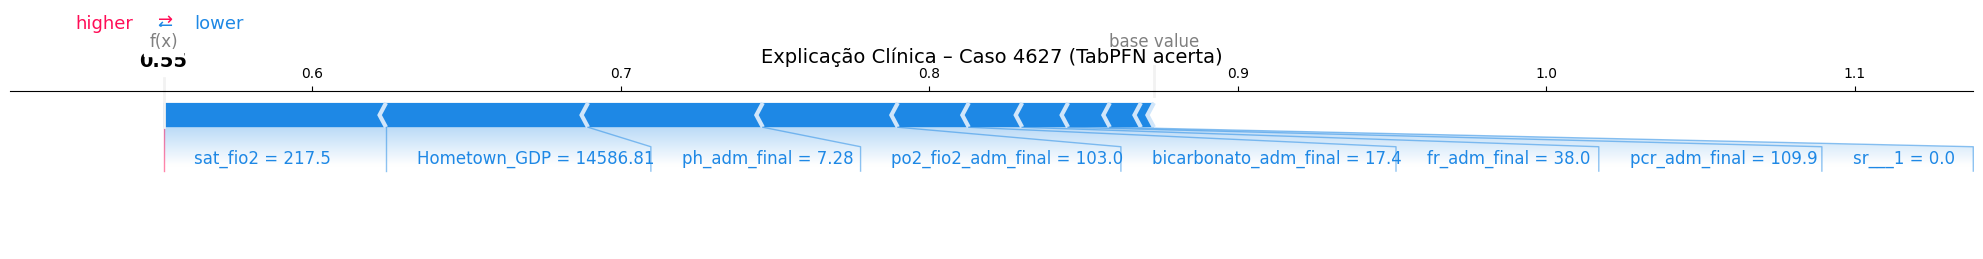

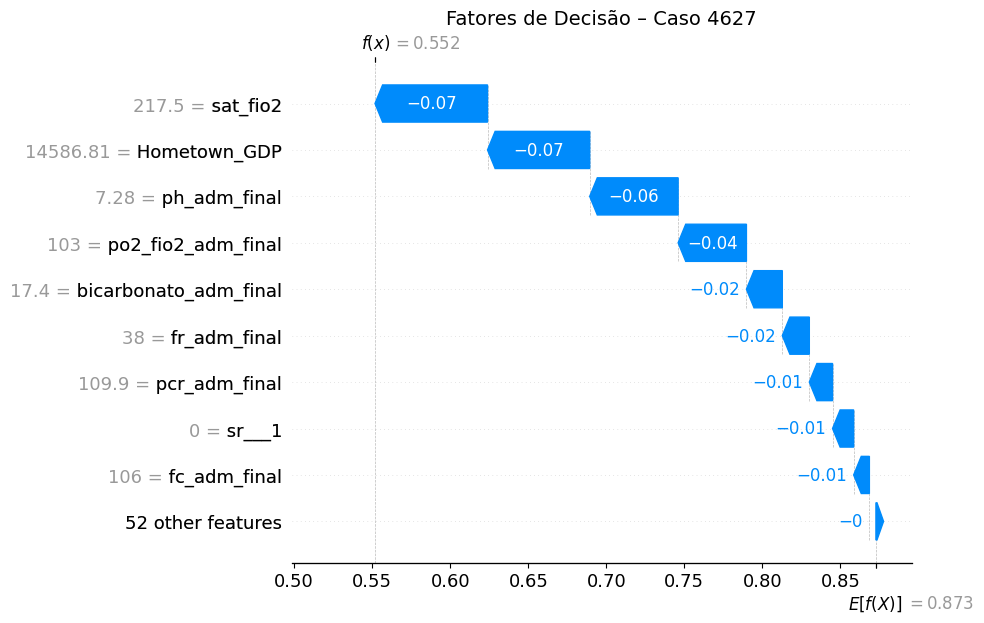

In [22]:
import shap
import pandas as pd
import numpy as np
import xgboost as xgb
from tabpfn import TabPFNClassifier
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt


# ============================================================
# 1. IDENTIFICAÇÃO DOS CASOS DIVERGENTES
# ============================================================
def analisar_divergencias_shap(df, target_col):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    casos_divergentes = []

    print("Iniciando busca por divergências (TabPFN correto vs XGBoost errado)...")

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"\n--- Fold {fold_i} ---")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # ---------------------
        # XGBoost
        # ---------------------
        model_xgb = xgb.XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=7
        )
        model_xgb.fit(X_train, y_train)
        pred_xgb = model_xgb.predict(X_test)

        # ---------------------
        # TabPFN
        # ---------------------
        model_tab = TabPFNClassifier(
            device='cuda',
            ignore_pretraining_limits=True,
            random_state=7
        )
        model_tab.fit(X_train, y_train)
        pred_tab = model_tab.predict(X_test)

        # ---------------------
        # Divergência
        # ---------------------
        mask_divergencia = (
            (pred_tab == y_test.values) &
            (pred_xgb != y_test.values)
        )

        indices_divergentes = X_test.index[mask_divergencia]

        print(f"Casos divergentes no fold {fold_i}: {len(indices_divergentes)}")

        for idx in indices_divergentes:
            pos = X_test.index.get_loc(idx)

            casos_divergentes.append({
                'fold': fold_i,
                'original_index': idx,
                'true_label': int(y_test.loc[idx]),
                'xgb_pred': int(pred_xgb[pos]),
                'tab_pred': int(pred_tab[pos]),
                'row_data': X_test.loc[[idx]],
                'model_tab_instance': model_tab,
                'background_data': X_train.sample(50, random_state=42)
            })

    print("\n======================================")
    print(f"TOTAL de casos divergentes encontrados: {len(casos_divergentes)}")

    indices_finais = sorted(set(c['original_index'] for c in casos_divergentes))
    print(f"Índices divergentes (originais do df):\n{indices_finais}")
    print("======================================")

    return casos_divergentes


# ============================================================
# 2. EXPLICAÇÃO CLÍNICA COM SHAP (TabPFN)
# ============================================================
def plotar_explicacao_clinica(caso, feature_names):
    print(f"\n--- Analisando Caso Clínico ---")
    print(f"Index original: {caso['original_index']}")
    print(
        f"Real: {caso['true_label']} | "
        f"TabPFN: {caso['tab_pred']} (correto) | "
        f"XGBoost: {caso['xgb_pred']} (errado)"
    )

    model = caso['model_tab_instance']
    row = caso['row_data']
    background = caso['background_data']
    classe_interesse = int(caso['true_label'])

    print(f"Classe de interesse para explicação: {classe_interesse}")

    # Função para o KernelExplainer
    def predict_proba_classe_interesse(X):
        return model.predict_proba(X)[:, classe_interesse]

    explainer = shap.KernelExplainer(
        predict_proba_classe_interesse,
        background
    )

    with np.errstate(all="ignore"):
        shap_values = explainer.shap_values(
            row,
            nsamples=100,
            silent=True
        )

    base_value = float(explainer.expected_value)

    if isinstance(shap_values, list):
        shap_values = np.array(shap_values)

    if shap_values.ndim == 2:
        shap_values = shap_values[0]

    row_np = row.values[0].astype(float)
    feature_names_list = feature_names.astype(str).tolist()

    # ---------------------
    # DEBUG CONTROLADO
    # ---------------------
    print("\n--- DEBUG SHAP ---")
    print("base_value:", base_value)
    print("shap_values shape:", shap_values.shape)
    print("row_data shape:", row_np.shape)
    print("-----------------\n")

    # ---------------------
    # FORCE PLOT
    # ---------------------
    plt.figure(figsize=(28, 7))
    shap.force_plot(
        base_value,
        shap_values,
        row_np,
        feature_names=feature_names_list,
        matplotlib=True,
        show=False
    )
    plt.title(
        f"Explicação Clínica – Caso {caso['original_index']} (TabPFN acerta)",
        fontsize=14,
        pad=20
    )
    plt.tight_layout()
    plt.show()

    # ---------------------
    # WATERFALL
    # ---------------------
    sv = shap.Explanation(
        values=shap_values,
        base_values=base_value,
        data=row_np,
        feature_names=feature_names_list
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(sv, show=False)
    plt.title(
        f"Fatores de Decisão – Caso {caso['original_index']}",
        fontsize=14
    )
    plt.show()


# ============================================================
# 3. EXECUÇÃO
# ============================================================
casos = analisar_divergencias_shap(df, target_col='obito')

# ============================================================
# 3. EXECUÇÃO – CASO ESPECÍFICO (index = 2571)
# ============================================================
indice_desejado = 4627

caso_2571 = next(
    (c for c in casos if c['original_index'] == indice_desejado),
    None
)

if caso_2571 is not None:
    plotar_explicacao_clinica(
        caso_2571,
        feature_names=df.drop(columns=['obito']).columns
    )
else:
    print(f"O caso {indice_desejado} não foi encontrado entre os casos divergentes.")


In [16]:
original_index = 2571

✅ DataFrame real carregado com sucesso.

Procurando caso 2571 e treinando modelo no fold de teste...
✅ Caso 2571 encontrado no Fold 2 de teste.

--- Análise SHAP para Índice 2571 ---
REAL: 0.0 | Predição XGBoost: 1
Atenção: A divergência Real=1/Pred=0 pode ter sido resolvida com este seed/fold.


/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:21:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 2000x600 with 0 Axes>

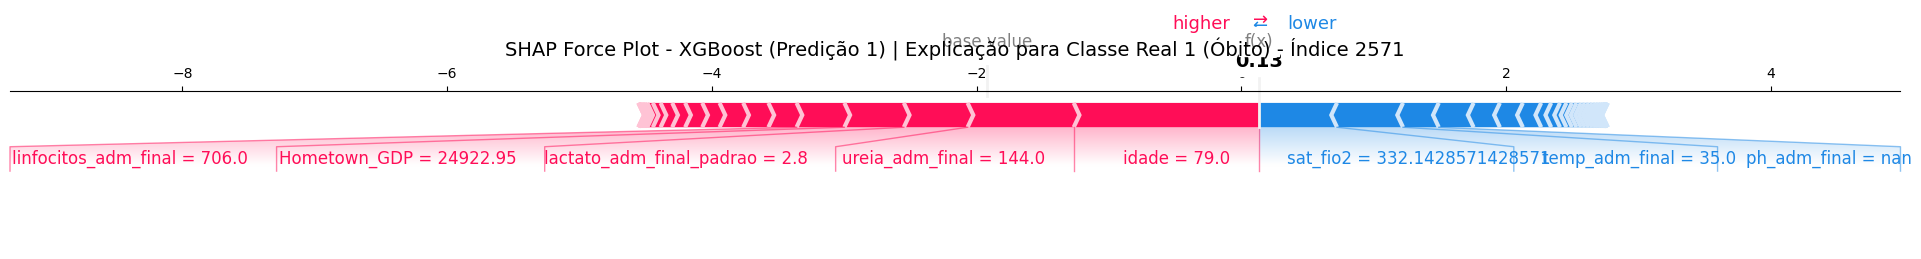

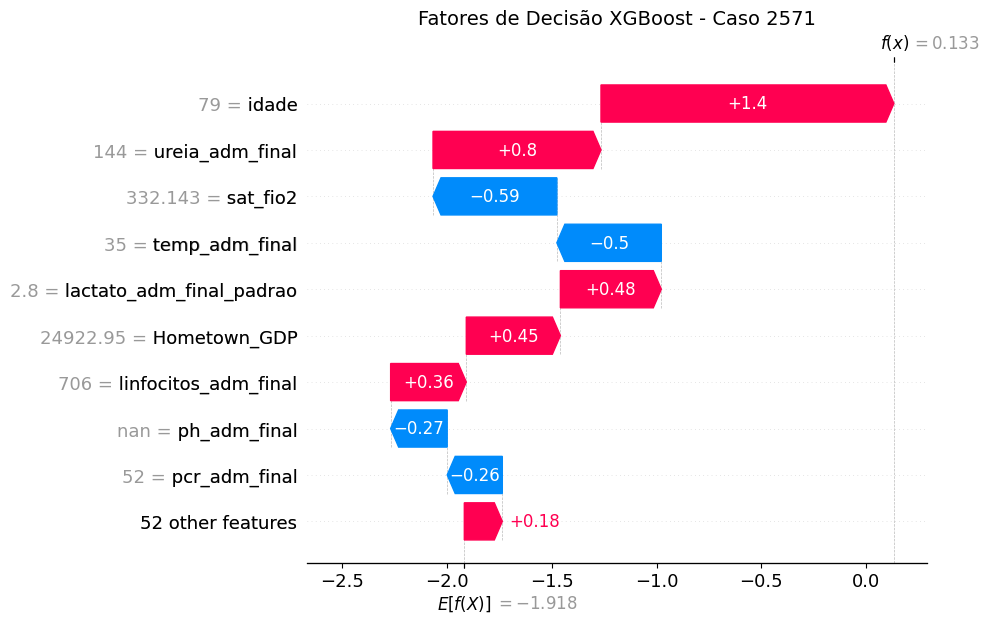

In [8]:
import shap
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# --- 1. CONFIGURAÇÃO E CARREGAMENTO DOS DADOS REAIS ---
original_index_divergente = 2571
target_col = 'obito'
random_seed = 42
n_splits = 5

try:
    # Carrega o DataFrame real
    df = pd.read_parquet('Base_onda_Onda 1_desfecho_obito_variaveis_all.parquet')
    
    # Prepara X e y
    X_full = df.drop(columns=[target_col])
    y_full = df[target_col]
    feature_names_list = X_full.columns.tolist()
    
    print("✅ DataFrame real carregado com sucesso.")

except FileNotFoundError:
    print("❌ ERRO: Arquivo 'Base_onda_Onda 1_desfecho_obito_variaveis_all.parquet' não encontrado.")
    print("O código está abortando, pois os dados reais são necessários.")
    exit()

# ----------------------------------------------------------------------
# --- 2. IDENTIFICAÇÃO DO CASO E TREINAMENTO ESPECÍFICO DO FOLD ---
# ----------------------------------------------------------------------

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
caso_encontrado = None

print(f"\nProcurando caso {original_index_divergente} e treinando modelo no fold de teste...")

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_full, y_full)):
    X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]

    # Verifica se o índice 2571 está no conjunto de TESTE deste fold
    if original_index_divergente in X_test.index:
        
        # 2a. Treinamento do Modelo XGBoost
        model_xgb = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=7)
        model_xgb.fit(X_train, y_train)

        # 2b. Seleciona a linha de dados e verifica a predição
        row_data = X_test.loc[[original_index_divergente]]
        true_label = y_test.loc[original_index_divergente]
        xgb_pred = model_xgb.predict(row_data)[0]

        caso_encontrado = {
            'row_data': row_data,
            'true_label': true_label,
            'xgb_pred': xgb_pred,
            'model_xgb_instance': model_xgb,
            'feature_names': X_full.columns.tolist()
        }
        print(f"✅ Caso {original_index_divergente} encontrado no Fold {fold_i} de teste.")
        break 

if caso_encontrado:
    
    true_label = caso_encontrado['true_label']
    xgb_pred = caso_encontrado['xgb_pred']
    row_data = caso_encontrado['row_data']
    model_xgb = caso_encontrado['model_xgb_instance']
    feature_names_list = caso_encontrado['feature_names']
    
    classe_interesse = 1 # Foco na classe real (obito = 1)

    print(f"\n--- Análise SHAP para Índice {original_index_divergente} ---")
    print(f"REAL: {true_label} | Predição XGBoost: {xgb_pred}")
    if true_label == classe_interesse and xgb_pred != classe_interesse:
        print(f"Objetivo: Explicar por que o modelo errou a Classe {classe_interesse}.")
    else:
        print("Atenção: A divergência Real=1/Pred=0 pode ter sido resolvida com este seed/fold.")


    # --- 3. APLICAÇÃO DO SHAP NATIVO (TreeExplainer) ---
    explainer_xgb = shap.TreeExplainer(model_xgb)
    shap_values_xgb = explainer_xgb.shap_values(row_data, check_additivity=False)
    
    # Lógica de correção para tratar saída de lista [C0, C1] ou array único [C1]
    if isinstance(shap_values_xgb, list):
        shap_values_vector = shap_values_xgb[classe_interesse]
        base_value = explainer_xgb.expected_value[classe_interesse]
    elif isinstance(shap_values_xgb, np.ndarray) and shap_values_xgb.ndim == 2 and shap_values_xgb.shape[0] == 1:
        shap_values_vector = shap_values_xgb[0] 
        if isinstance(explainer_xgb.expected_value, np.ndarray):
            base_value = explainer_xgb.expected_value[classe_interesse]
        else:
            base_value = explainer_xgb.expected_value
    else:
         raise ValueError("Formato inesperado dos valores SHAP retornados.")

    # --- 4. PLOTAGEM DOS RESULTADOS SHAP ---
    
    # 4a. Force Plot (Usando DataFrame 'row_data' para exibir os valores reais das features)
    plt.figure(figsize=(20, 6))
    plt.rcParams['font.size'] = 10
    
    # 
    
    shap.force_plot(
        base_value,                 
        shap_values_vector,         
        row_data,              
        feature_names=feature_names_list, 
        matplotlib=True,
        show=False
    )

    plt.title(
        f"SHAP Force Plot - XGBoost (Predição {xgb_pred}) | Explicação para Classe Real 1 (Óbito) - Índice {original_index_divergente}",
        pad=25,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

    # 4b. Waterfall Plot
    sv = shap.Explanation(
        values=shap_values_vector,
        base_values=base_value, 
        data=row_data.values[0], 
        feature_names=feature_names_list
    )
    
    plt.figure()
    shap.plots.waterfall(sv, show=False)
    plt.title(f"Fatores de Decisão XGBoost - Caso {original_index_divergente}", fontsize=14)
    plt.show()

else:
    print(f"Não foi possível encontrar o índice {original_index_divergente} no conjunto de teste em nenhum dos folds com a seed {random_seed}. Tente alterar a semente (random_state) ou o número de folds.")

✅ DataFrame real carregado com sucesso.


/home/izadoraganem/.pyenv/versions/3.12.7/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:45:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 2000x600 with 0 Axes>

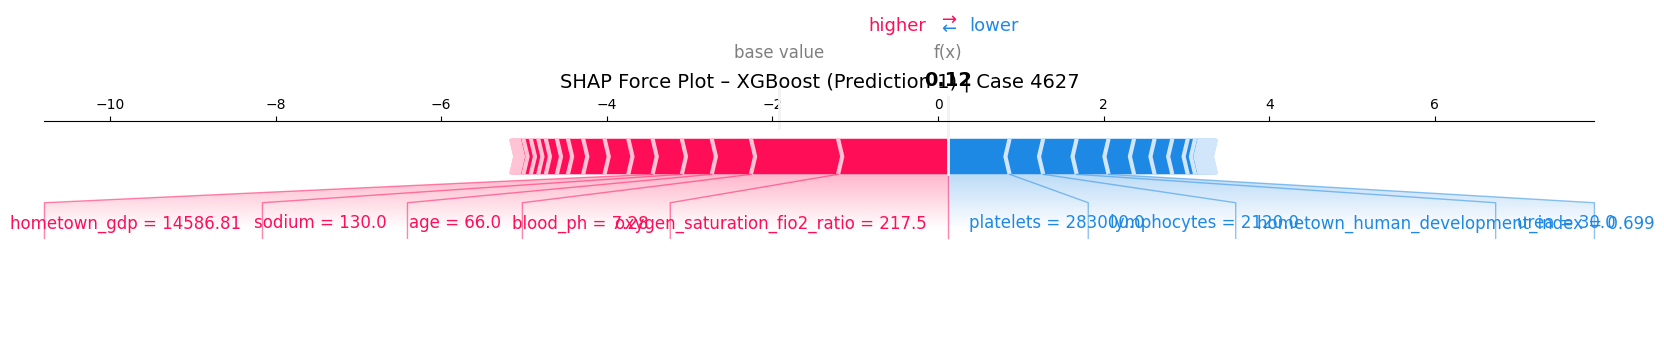

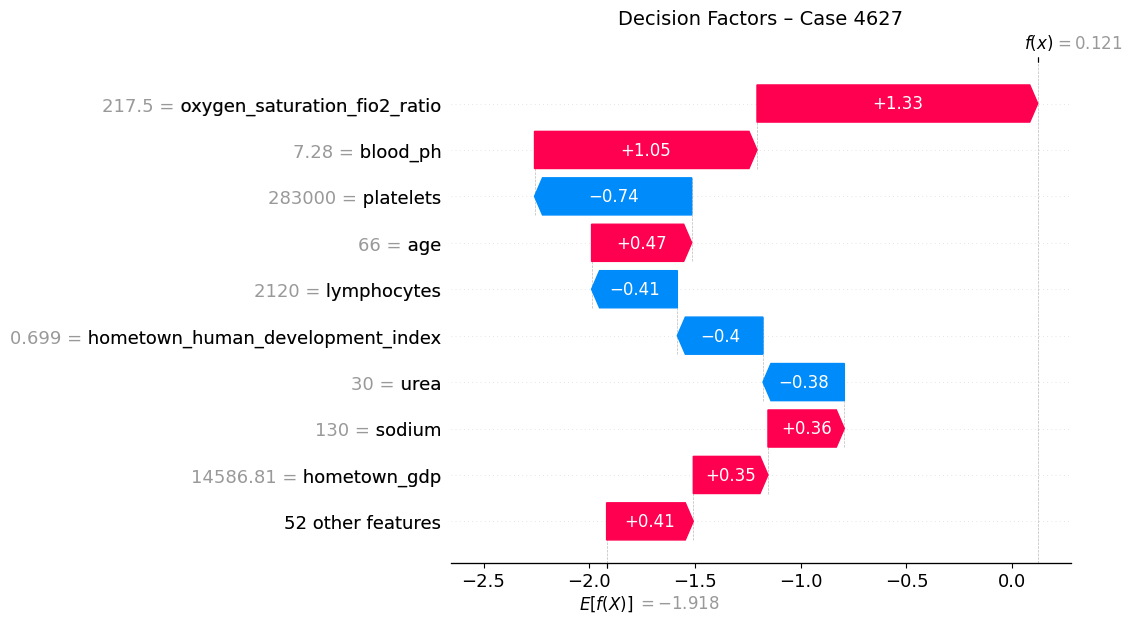

In [26]:
import shap
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# ==============================
# Feature name map (PT → EN)
# ==============================
FEATURE_NAME_MAP = {
    "idade": "age",
    "sexo": "sex",
    "scv___1": "cardiovascular_disease_1",
    "scv___2": "cardiovascular_disease_2",
    "scv___3": "cardiovascular_disease_3",
    "scv___4": "cardiovascular_disease_4",
    "scv___5": "cardiovascular_disease_5",
    "scv___6": "cardiovascular_disease_6",
    "sr___1": "systemic_response_1",
    "sr___2": "systemic_response_2",
    "sr___3": "systemic_response_3",
    "dm___1": "diabetes_mellitus_1",
    "dm___2": "diabetes_mellitus_2",
    "comorb_outras___1": "other_comorbidities_1",
    "comorb_outras___3": "other_comorbidities_3",
    "comorb_outras___4": "other_comorbidities_4",
    "comorb_outras___5": "other_comorbidities_5",
    "comorb_outras___6": "other_comorbidities_6",
    "comorb_outras___8": "other_comorbidities_8",
    "comorb_outras___11": "other_comorbidities_11",
    "comorb_outras_dialise": "dialysis_dependent_comorbidity",
    "med_domiciliar___3": "home_medication_3",
    "med_domiciliar___6": "home_medication_6",
    "med_domiciliar___7": "home_medication_7",
    "med_domiciliar___13": "home_medication_13",
    "hv___1": "clinical_history_1",
    "hv___2": "clinical_history_2",
    "hv___3": "clinical_history_3",
    "hv___4": "clinical_history_4",
    "glasgow_menor15_adm_final": "glasgow_coma_scale_less_than_15",
    "fc_adm_final": "heart_rate",
    "fr_adm_final": "respiratory_rate",
    "temp_adm_final": "body_temperature",
    "sat_fio2": "oxygen_saturation_fio2_ratio",
    "vm_adm_final": "mechanical_ventilation",
    "hb_adm_final": "hemoglobin",
    "leucocitos_adm_final": "leukocytes",
    "neutrofilos_adm_final": "neutrophils",
    "linfocitos_adm_final": "lymphocytes",
    "plaquetas_adm_final": "platelets",
    "creatinina_adm_final": "creatinine",
    "lactato_adm_final_padrao": "lactate",
    "pcr_adm_final": "c_reactive_protein",
    "sodio_adm_final": "sodium",
    "ast_alt": "ast_alt_ratio",
    "ureia_adm_final": "urea",
    "ph_adm_final": "blood_ph",
    "pco2_adm_final": "pco2",
    "bicarbonato_adm_final": "bicarbonate",
    "po2_fio2_adm_final": "pao2_fio2_ratio",
    "pasamina90": "systolic_bp_below_90",
    "padamina60": "diastolic_bp_below_60",
    "vacina": "vaccination_status",
    "dimero_adm_final_relacao": "d_dimer_ratio",
    "Hometown_GDP": "hometown_gdp",
    "Hometown_DHI": "hometown_human_development_index",
    "Hospital_GDP": "hospital_region_gdp",
    "Hospital_DHI": "hospital_region_human_development_index",
    "Academic_status": "hospital_academic_status",
    "Accreditation": "hospital_accreditation",
    "Source_of_income": "source_of_income",
    "obito": "mortality",
}

# ----------------------------------------------------------------------
# --- 1. CONFIGURATION & DATA LOADING ---
# ----------------------------------------------------------------------
original_index_divergente = 4627
target_col = "obito"
random_seed = 42
n_splits = 5

df = pd.read_parquet("Base_onda_Onda 1_desfecho_obito_variaveis_all.parquet")

X_full = df.drop(columns=[target_col])
y_full = df[target_col]

# 🔹 TRANSLATED FEATURE NAMES
feature_names_list = [
    FEATURE_NAME_MAP.get(f, f)
    for f in X_full.columns.astype(str).tolist()
]

print("✅ DataFrame real carregado com sucesso.")

# ----------------------------------------------------------------------
# --- 2. FIND CASE AND TRAIN MODEL ---
# ----------------------------------------------------------------------
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
caso_encontrado = None

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_full, y_full)):
    X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]

    if original_index_divergente in X_test.index:
        model_xgb = xgb.XGBClassifier(
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=7
        )
        model_xgb.fit(X_train, y_train)

        row_data = X_test.loc[[original_index_divergente]]
        true_label = y_test.loc[original_index_divergente]
        xgb_pred = model_xgb.predict(row_data)[0]

        caso_encontrado = {
            "row_data": row_data,
            "true_label": true_label,
            "xgb_pred": xgb_pred,
            "model_xgb": model_xgb
        }
        break

# ----------------------------------------------------------------------
# --- 3. SHAP EXPLANATION ---
# ----------------------------------------------------------------------
if caso_encontrado:
    model_xgb = caso_encontrado["model_xgb"]
    row_data = caso_encontrado["row_data"]
    true_label = caso_encontrado["true_label"]
    xgb_pred = caso_encontrado["xgb_pred"]

    classe_interesse = 1

    explainer = shap.TreeExplainer(model_xgb)
    shap_values = explainer.shap_values(row_data, check_additivity=False)

    if isinstance(shap_values, list):
        shap_values_vector = shap_values[classe_interesse]
        base_value = explainer.expected_value[classe_interesse]
    else:
        shap_values_vector = shap_values[0]
        base_value = explainer.expected_value

    # --- FORCE PLOT ---
    plt.figure(figsize=(20, 6))
    shap.force_plot(
        base_value,
        shap_values_vector,
        row_data,
        feature_names=feature_names_list,
        matplotlib=True,
        show=False
    )
    plt.title(
        f"SHAP Force Plot – XGBoost (Prediction {xgb_pred}) | Case {original_index_divergente}",
        fontsize=14,
        pad=25
    )
    plt.show()
    plt.title(
        f"Decision Factors – Case 4627",
        fontsize=14
    )

    # --- WATERFALL ---
    sv = shap.Explanation(
        values=shap_values_vector,
        base_values=base_value,
        data=row_data.values[0],
        feature_names=feature_names_list
    )

    shap.plots.waterfall(sv, show=True)
    

else:
    print("❌ Caso não encontrado nos folds.")
